In [97]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

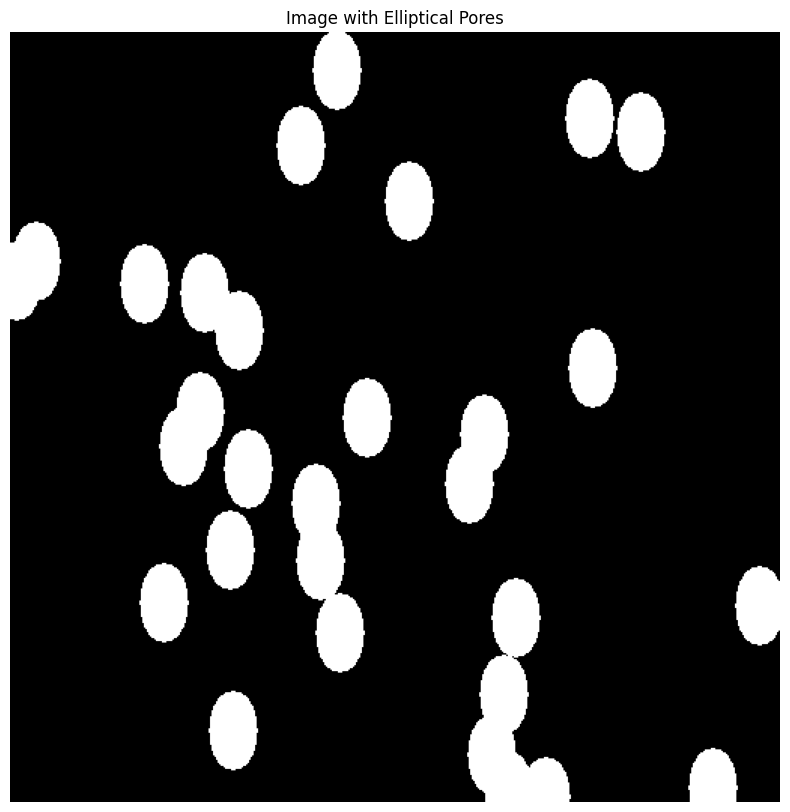

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, generate_binary_structure

def create_elliptical_pore_image(shape, a, b, num_pores, connectivity):
    """
    Generate a binary image with elliptical pores.
    
    Parameters:
        shape (tuple): Shape of the output image (height, width).
        a (float): Semi-major axis length of the elliptical pores.
        b (float): Semi-minor axis length of the elliptical pores.
        num_pores (int): Number of elliptical pores to generate.
        connectivity (float): Fraction of pores that are connected (0 to 1).
        
    Returns:
        np.ndarray: Binary image with elliptical pores.
    """
    image = np.zeros(shape, dtype=np.uint8)
    
    # Generate random positions for the pores
    pore_centers = np.random.randint(0, min(shape), size=(num_pores, 2))
    
    for center in pore_centers:
        h, k = center
        y, x = np.ogrid[:shape[0], :shape[1]]
        mask = ((x - h)**2 / a**2) + ((y - k)**2 / b**2) <= 1
        image[mask] = 1
    
    # Apply connectivity if necessary
    if connectivity > 0:
        struct = generate_binary_structure(2, 2)  # 8-connectivity structure
        num_iterations = int(connectivity * 10)  # Scale connectivity to a reasonable range
        image = binary_dilation(image, structure=struct, iterations=num_iterations)
    
    return image

def display_image(image):
    """
    Display a binary image.
    
    Parameters:
        image (np.ndarray): Binary image to display.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray')
    plt.title("Image with Elliptical Pores")
    plt.axis('off')
    plt.show()

# Parameters
shape = (512, 512)         # Image shape
a = 15                     # Semi-major axis length of elliptical pores
b = 25                     # Semi-minor axis length of elliptical pores
num_pores = 30            # Number of pores
connectivity = 0.1         # Fraction of pores that are connected

# Generate and display the image
image = create_elliptical_pore_image(shape, a, b, num_pores, connectivity)
display_image(image)

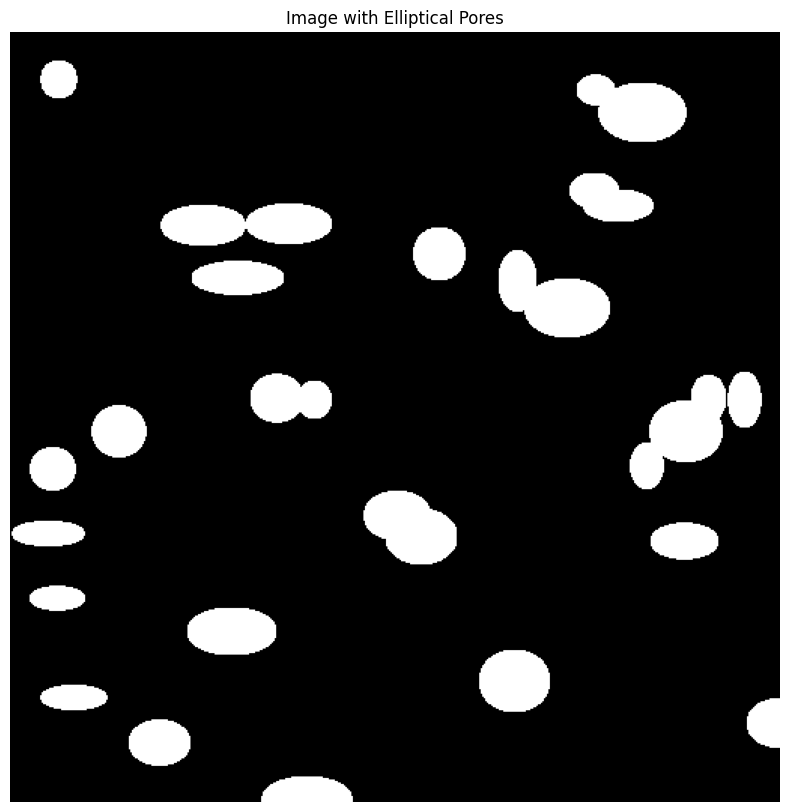

In [302]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, generate_binary_structure

def create_elliptical_pore_image(shape, a_range, b_range, num_pores, connectivity):
    """
    Generate a binary image with elliptical pores of varied sizes.
    
    Parameters:
        shape (tuple): Shape of the output image (height, width).
        a_range (tuple): Range (min, max) of semi-major axis lengths of the elliptical pores.
        b_range (tuple): Range (min, max) of semi-minor axis lengths of the elliptical pores.
        num_pores (int): Number of elliptical pores to generate.
        connectivity (float): Fraction of pores that are connected (0 to 1).
        
    Returns:
        np.ndarray: Binary image with elliptical pores.
    """
    image = np.zeros(shape, dtype=np.uint8)
    
    # Generate random positions for the pores
    pore_centers = np.random.randint(0, min(shape), size=(num_pores, 2))
    
    for center in pore_centers:
        h, k = center
        # Generate random semi-major and semi-minor axis lengths
        a = np.random.uniform(a_range[0], a_range[1])
        b = np.random.uniform(b_range[0], b_range[1])
        y, x = np.ogrid[:shape[0], :shape[1]]
        mask = ((x - h)**2 / a**2) + ((y - k)**2 / b**2) <= 1
        image[mask] = 1
    
    # Apply connectivity if necessary
    if connectivity > 0:
        struct = generate_binary_structure(2, 2)  # 8-connectivity structure
        num_iterations = int(connectivity * 10)  # Scale connectivity to a reasonable range
        image = binary_dilation(image, structure=struct, iterations=num_iterations)
    
    return image

def display_image(image):
    """
    Display a binary image.
    
    Parameters:
        image (np.ndarray): Binary image to display.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray')
    plt.title("Image with Elliptical Pores")
    plt.axis('off')
    plt.show()

# Parameters
shape = (512, 512)         # Image shape
a_range = (10, 30)         # Range of semi-major axis lengths of elliptical pores
b_range = (5, 20)          # Range of semi-minor axis lengths of elliptical pores
num_pores = 30            # Number of pores
connectivity = 0.1         # Fraction of pores that are connected

# Generate and display the image
image = create_elliptical_pore_image(shape, a_range, b_range, num_pores, connectivity)
display_image(image)


In [303]:
image.shape

(512, 512)

In [304]:
image = image.astype("uint8")

In [305]:
# image[:25,:25]

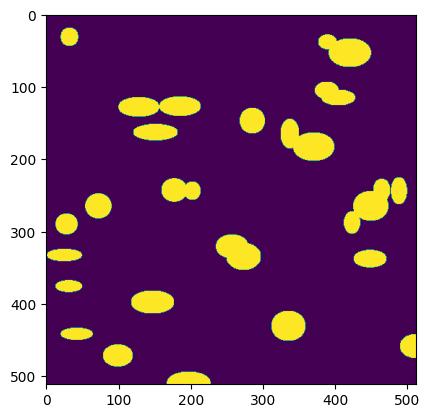

In [306]:
plt.imshow(image)

In [243]:
binary_image = image

In [244]:
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [245]:
num_labels

24

In [300]:
labeled_image.min(), labeled_image.max()

(0, 24)

In [246]:
im = image

In [247]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 18


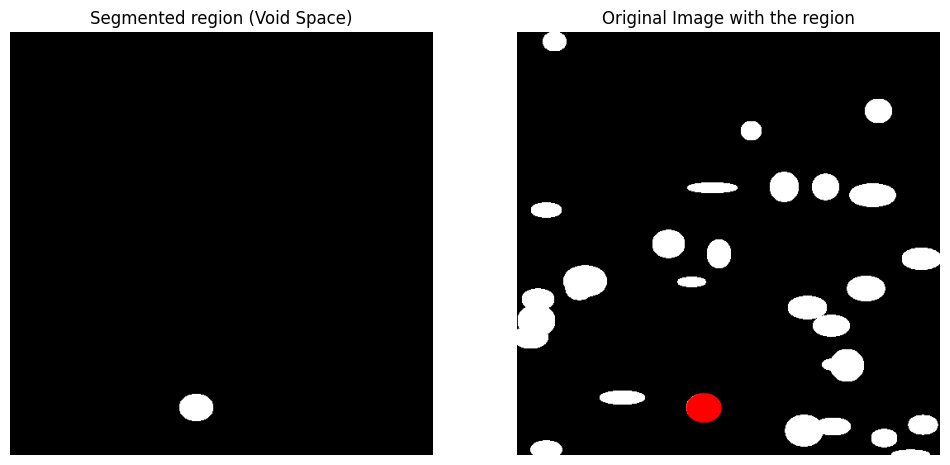

In [248]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [169]:
# The number of pixels to consider a pore

pore_number = 1080 # This is the ideal cluster to the shape (384, 512) pirabasb_2

In [170]:
pore_number

1080

In [171]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours, label, regionprops

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers

def calculate_aspect_ratios(contornos_por_cluster):
    aspect_ratios = []
    for contornos in contornos_por_cluster:
        for contorno in contornos:
            if len(contorno) < 5:
                continue
            # Encontrar as propriedades da região contornada
            x_min, y_min = np.min(contorno, axis=0)
            x_max, y_max = np.max(contorno, axis=0)
            major_axis_length = y_max - y_min
            minor_axis_length = x_max - x_min
            # Calcular a razão de aspecto
            if major_axis_length > 0:  # Evitar divisão por zero
                aspect_ratio = minor_axis_length / major_axis_length
            else:
                aspect_ratio = 0
            aspect_ratios.append(aspect_ratio)
    return aspect_ratios






#
# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
#areas_cluster_kmeans = []
#contour_per_cluster = []
ratio_of_aspect_cluster_kmeans = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)

    # Calcular as razões de aspecto dos clusters
    #aspect_ratios_kmeans = calculate_aspect_ratios(contornos_por_cluster)
    # ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)

    # Calcular as áreas dos clusters
    #areas_kmeans = calculate_areas(clustered_region_kmeans)
    #areas_cluster_kmeans.append(areas_kmeans)

    # Armazenar os contornos dos clusters
    #contour_per_cluster.append(contornos_por_cluster)

# # Exemplo de uso dos resultados
# for i, aspect_ratios in enumerate(ratio_of_aspect_cluster_kmeans):
#     print(f'Região {i+1}: Razões de aspecto dos clusters = {aspect_ratios}')

C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

In [211]:
len(resultados_kmeans)

20

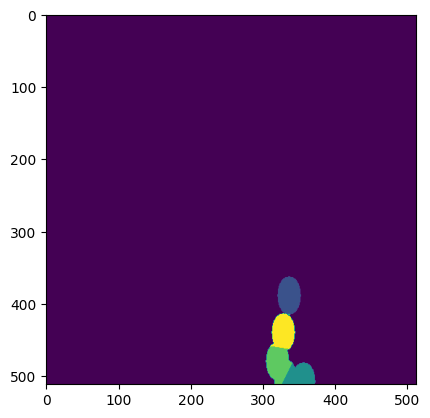

In [213]:
plt.imshow(resultados_kmeans[17])

## Apply the gaussian mixture;
The best clusterized method
the basic idea is that you are supposed to select the ideal pore_number

In [249]:
import numpy as np
from sklearn.mixture import GaussianMixture
from skimage.measure import find_contours, label, regionprops


In [287]:
pore_number = 900

In [288]:
def apply_gmm_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar GMM aos pixels 0 para segmentá-los em clusters
    gmm = GaussianMixture(n_components=num_clusters, random_state=42)
    gmm.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = gmm.predict(pixels_0)

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = gmm.means_

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers


In [289]:
# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_gmm = []
resultados_gmm = []
number_of_pores_gmm = []
ratio_of_aspect_cluster_gmm = []

# Plotar as regiões segmentadas após a aplicação do GMM
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o GMM à região segmentada atual
    clustered_region_gmm, n_por_gmm, centros_gmm = apply_gmm_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_gmm.append(centros_gmm)
    resultados_gmm.append(clustered_region_gmm)
    number_of_pores_gmm.append(n_por_gmm)

    # Calcular as razões de aspecto dos clusters
    #contornos_por_cluster = [find_contours(clustered_region_gmm == label, 0.5) for label in range(1, n_por_gmm + 1)]
    #aspect_ratios_gmm = calculate_aspect_ratios(contornos_por_cluster)
    #ratio_of_aspect_cluster_gmm.append(aspect_ratios_gmm)

# Exemplo de uso dos resultados
# for i, aspect_ratios in enumerate(ratio_of_aspect_cluster_gmm):
#     print(f'Região {i+1}: Razões de aspecto dos clusters = {aspect_ratios}')


C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklea

In [290]:
len(resultados_gmm)

24

In [291]:
resultados_gmm = np.array(resultados_gmm)

In [292]:
resultados_gmm = resultados_gmm.astype("uint8")

In [293]:
resultados_gmm[0].max(), resultados_gmm[1].max()

(1, 1)

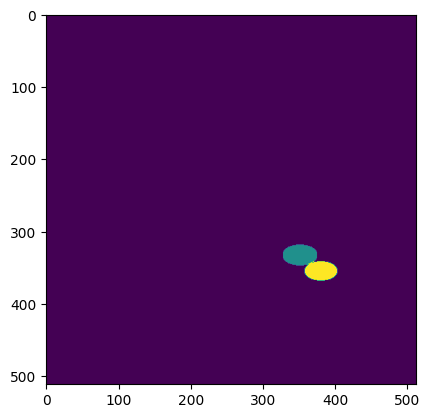

In [297]:
plt.imshow(resultados_gmm[15])

In [295]:
resultados_gmm[13].max(), resultados_gmm[13].min()

(1, 0)

## Apply the gaussian mixture with shape criteria


In [194]:
import numpy as np
from sklearn.mixture import GaussianMixture
from skimage.measure import regionprops

def apply_gmm_to_region(region_segmentada, initial_pore_number):
    pixels_0 = np.argwhere(region_segmentada == 1)
    n_samples = len(pixels_0)
    n_components = min(initial_pore_number, n_samples)

    if n_components <= 1:
        raise ValueError("Number of components must be at least 1")

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(pixels_0)
    labels = gmm.predict(pixels_0)
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1
    return clustered_region, gmm.means_

def calculate_aspect_ratios(clustered_region):
    aspect_ratios = []
    for region_label in np.unique(clustered_region):
        if region_label == 0:
            continue
        region_mask = clustered_region == region_label
        props = regionprops(region_mask.astype(int))
        for prop in props:
            major_axis_length = prop.major_axis_length
            minor_axis_length = prop.minor_axis_length
            if major_axis_length == 0 or minor_axis_length == 0:
                continue
            aspect_ratio = minor_axis_length / major_axis_length
            aspect_ratios.append((aspect_ratio, region_label))
    return aspect_ratios

def refine_clusters_by_shape(region_segmentada, pore_number, min_aspect_ratio=0.5, max_aspect_ratio=3.0, max_iterations=10):
    iteration = 0
    while iteration < max_iterations:
        clustered_region, _ = apply_gmm_to_region(region_segmentada, pore_number)
        aspect_ratios = calculate_aspect_ratios(clustered_region)
        valid_clusters = [label for aspect_ratio, label in aspect_ratios if min_aspect_ratio <= aspect_ratio <= max_aspect_ratio]

        if len(valid_clusters) == pore_number:
            refined_region = np.zeros_like(clustered_region)
            new_label = 1
            for label in valid_clusters:
                refined_region[clustered_region == label] = new_label
                new_label += 1
            return refined_region

        pore_number = len(valid_clusters)
        iteration += 1

    return clustered_region

# Main script
coordenadas_centros_gmm = []
resultados_gmm = []
number_of_pores_gmm = []

# Plotar as regiões segmentadas após a aplicação do GMM
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    refined_clustered_region = refine_clusters_by_shape(region_segmentada, pore_number)
    resultados_gmm.append(refined_clustered_region)
    number_of_pores_gmm.append(len(np.unique(refined_clustered_region)) - 1)

# Example usage of results
for i, (refined_region, num_pores) in enumerate(zip(resultados_gmm, number_of_pores_gmm)):
    print(f'Região {i+1}: Número de poros refinados = {num_pores}')


C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklea

Região 1: Número de poros refinados = 50
Região 2: Número de poros refinados = 75
Região 3: Número de poros refinados = 75
Região 4: Número de poros refinados = 75
Região 5: Número de poros refinados = 75
Região 6: Número de poros refinados = 50
Região 7: Número de poros refinados = 75
Região 8: Número de poros refinados = 61
Região 9: Número de poros refinados = 75
Região 10: Número de poros refinados = 54
Região 11: Número de poros refinados = 75
Região 12: Número de poros refinados = 33
Região 13: Número de poros refinados = 75
Região 14: Número de poros refinados = 5
Região 15: Número de poros refinados = 75
Região 16: Número de poros refinados = 75
Região 17: Número de poros refinados = 53
Região 18: Número de poros refinados = 24
Região 19: Número de poros refinados = 75
Região 20: Número de poros refinados = 42


C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [195]:
len(resultados_gmm)

20

In [196]:
resultados_gmm = np.array(resultados_gmm)

In [197]:
resultados_gmm = resultados_gmm.astype("uint8")

In [198]:
resultados_gmm[0].max(), resultados_gmm[1].max()

(50, 75)

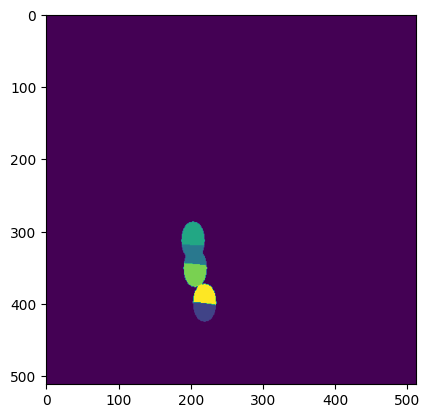

In [200]:
plt.imshow(resultados_gmm[13])

## Apply the cluster with DBSCAN
This version apply this algorithm with the shape criteria

In [217]:
num_pores

1

In [229]:
import numpy as np
from sklearn.cluster import DBSCAN
from skimage.measure import regionprops

def apply_dbscan_to_region(region_segmentada, eps, min_samples):
    pixels_0 = np.argwhere(region_segmentada == 1)
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(pixels_0)
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        if label != -1:  # Skip noise points
            clustered_region[pixel[0], pixel[1]] = label + 1
    return clustered_region

def calculate_aspect_ratios(clustered_region):
    aspect_ratios = []
    for region_label in np.unique(clustered_region):
        if region_label == 0:
            continue
        region_mask = clustered_region == region_label
        props = regionprops(region_mask.astype(int))
        for prop in props:
            major_axis_length = prop.major_axis_length
            minor_axis_length = prop.minor_axis_length
            if major_axis_length == 0 or minor_axis_length == 0:
                continue
            aspect_ratio = minor_axis_length / major_axis_length
            aspect_ratios.append((aspect_ratio, region_label))
    return aspect_ratios

def refine_clusters_by_shape(region_segmentada, eps, min_samples, min_aspect_ratio=0.5, max_aspect_ratio=3.0, max_iterations=10):
    iteration = 0
    while iteration < max_iterations:
        clustered_region = apply_dbscan_to_region(region_segmentada, eps, min_samples)
        aspect_ratios = calculate_aspect_ratios(clustered_region)
        valid_clusters = [label for aspect_ratio, label in aspect_ratios if min_aspect_ratio <= aspect_ratio <= max_aspect_ratio]

        if len(valid_clusters) == len(np.unique(clustered_region)) - 1:
            refined_region = np.zeros_like(clustered_region)
            new_label = 1
            for label in valid_clusters:
                refined_region[clustered_region == label] = new_label
                new_label += 1
            return refined_region

        min_samples = max(1, min_samples - 1)  # Adjust min_samples to attempt to refine the clusters
        iteration += 1

    return clustered_region

# Main script
coordenadas_centros_dbscan = []
resultados_dbscan = []
number_of_pores_dbscan = []

# Plotar as regiões segmentadas após a aplicação do DBSCAN
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    refined_clustered_region = refine_clusters_by_shape(region_segmentada, eps=1000, min_samples=100)
    resultados_dbscan.append(refined_clustered_region)
    number_of_pores_dbscan.append(len(np.unique(refined_clustered_region)) - 1)

# Example usage of results
for i, (refined_region, num_pores) in enumerate(zip(resultados_dbscan, number_of_pores_dbscan)):
    print(f'Região {i+1}: Número de poros refinados = {num_pores}')


Região 1: Número de poros refinados = 1
Região 2: Número de poros refinados = 1
Região 3: Número de poros refinados = 1
Região 4: Número de poros refinados = 1
Região 5: Número de poros refinados = 1
Região 6: Número de poros refinados = 1
Região 7: Número de poros refinados = 1
Região 8: Número de poros refinados = 1
Região 9: Número de poros refinados = 1
Região 10: Número de poros refinados = 1
Região 11: Número de poros refinados = 1
Região 12: Número de poros refinados = 1
Região 13: Número de poros refinados = 1
Região 14: Número de poros refinados = 1
Região 15: Número de poros refinados = 1
Região 16: Número de poros refinados = 1
Região 17: Número de poros refinados = 1
Região 18: Número de poros refinados = 1
Região 19: Número de poros refinados = 1
Região 20: Número de poros refinados = 1


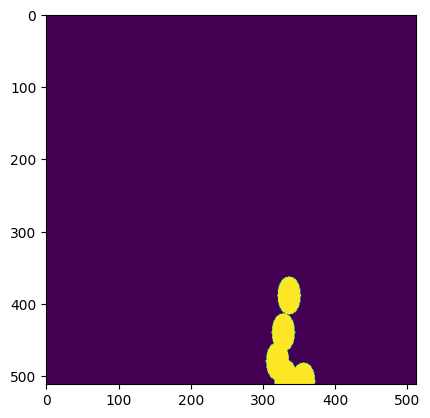

In [230]:
plt.imshow(resultados_dbscan[17])

In [267]:
image.shape

(512, 512)

C:\Users\CometLake_05\AppData\Local\Temp\ipykernel_16308\1782330148.py:10: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = hessian_matrix(image, sigma=1)


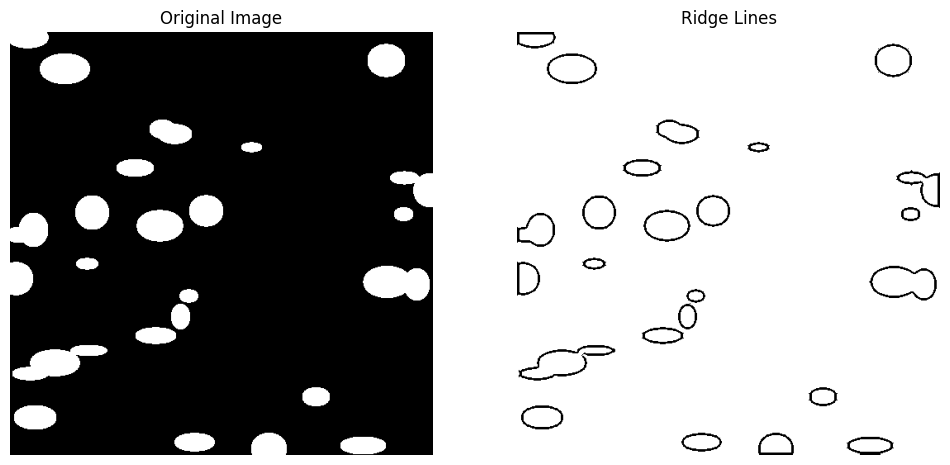

In [272]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.feature import hessian_matrix, hessian_matrix_eigvals

# Load an example image
#image = data.camera()

# Calculate the Hessian matrix
H_elems = hessian_matrix(image, sigma=1)

# Extract the eigenvalues of the Hessian matrix
eigvals = hessian_matrix_eigvals(H_elems)

# The ridge-like structures correspond to the second smallest eigenvalue
ridge_lines = eigvals[1]

# Threshold the ridge lines to enhance the visualization
threshold = filters.threshold_otsu(ridge_lines)
ridge_lines_binary = ridge_lines > threshold

# Display the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(ridge_lines_binary, cmap='gray')
ax[1].set_title('Ridge Lines')
ax[1].axis('off')

plt.show()


C:\Users\CometLake_05\AppData\Local\Temp\ipykernel_16308\3520650542.py:9: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = hessian_matrix(image.astype(float), sigma=2)


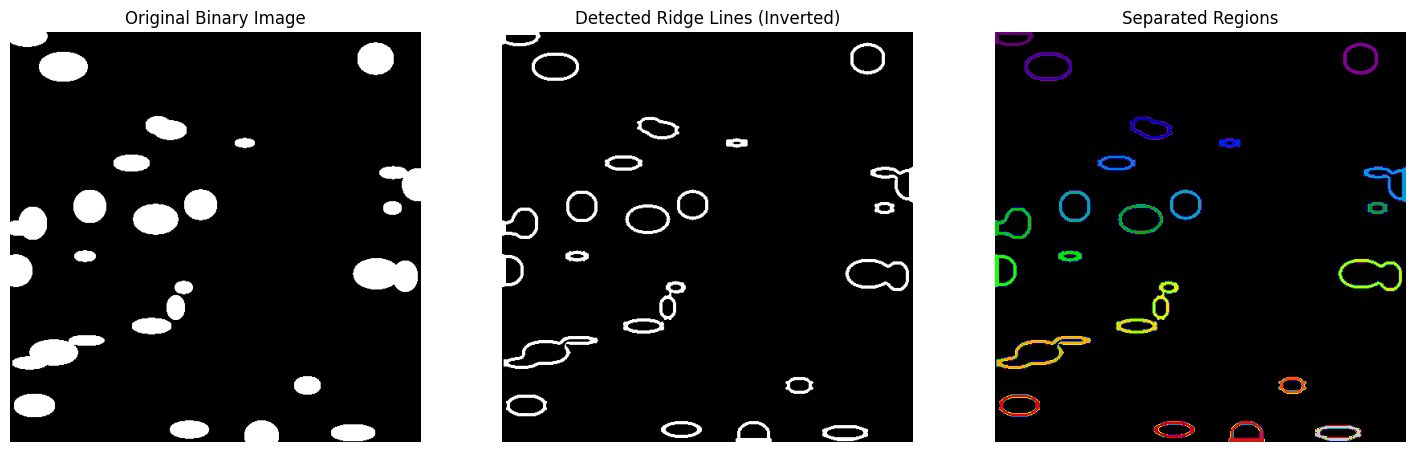

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
# Ensure the image is binary (only 0s and 1s)
image = image > 0

# Calculate the Hessian matrix
H_elems = hessian_matrix(image.astype(float), sigma=2)

# Extract the eigenvalues of the Hessian matrix
eigvals = hessian_matrix_eigvals(H_elems)

# The ridge-like structures correspond to the second smallest eigenvalue
ridge_lines = eigvals[1]

# Threshold the ridge lines to enhance the visualization
threshold = filters.threshold_otsu(ridge_lines)
ridge_lines_binary = ridge_lines > threshold

# Invert the ridge lines binary image
ridge_lines_binary = ~ridge_lines_binary

# Label connected regions
labeled_regions = measure.label(ridge_lines_binary, connectivity=2)

# Display the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Binary Image')
ax[0].axis('off')

ax[1].imshow(ridge_lines_binary, cmap='gray')
ax[1].set_title('Detected Ridge Lines (Inverted)')
ax[1].axis('off')

ax[2].imshow(labeled_regions, cmap='nipy_spectral')
ax[2].set_title('Separated Regions')
ax[2].axis('off')

plt.show()

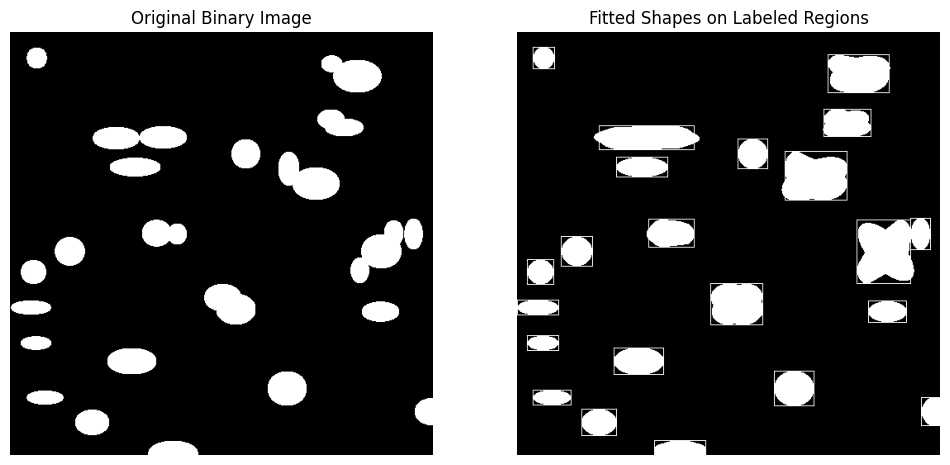

In [307]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, morphology, draw
from scipy import ndimage as ndi
from skimage.feature import hessian_matrix, hessian_matrix_eigvals


# Ensure the image is binary (only 0s and 1s)
binary_image = image > 0

# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

# Create an output image to draw the fitted shapes
output_image = np.zeros_like(binary_image)

# Function to draw an ellipse on the image
def draw_ellipse(image, region):
    y0, x0 = region.centroid
    orientation = region.orientation
    a = region.major_axis_length / 2
    b = region.minor_axis_length / 2
    
    y, x = draw.ellipse(y0, x0, a, b, rotation=-orientation)
    valid = ((0 <= y) & (y < image.shape[0]) & (0 <= x) & (x < image.shape[1]))
    image[y[valid], x[valid]] = 1

# Iterate over each labeled region and fit geometric shapes
for region in measure.regionprops(labeled_image):
    # Draw bounding box
    minr, minc, maxr, maxc = region.bbox
    rr, cc = draw.rectangle_perimeter((minr, minc), extent=(maxr - minr, maxc - minc), shape=image.shape)
    output_image[rr, cc] = 1

    # Draw convex hull
    hull = morphology.convex_hull_image(region.image)
    coords = np.argwhere(hull)
    coords[:, 0] += region.bbox[0]
    coords[:, 1] += region.bbox[1]
    output_image[coords[:, 0], coords[:, 1]] = 1

    # Draw ellipse
    if region.major_axis_length > 0 and region.minor_axis_length > 0:
        draw_ellipse(output_image, region)

# Display the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(binary_image, cmap='gray')
ax[0].set_title('Original Binary Image')
ax[0].axis('off')

ax[1].imshow(output_image, cmap='gray')
ax[1].set_title('Fitted Shapes on Labeled Regions')
ax[1].axis('off')

plt.show()


## Separate the clusterized regions, find the contours of each region and calculate the ratio of aspect

# The algorithm to connectivity

## Select the data to make the tests for connectivity

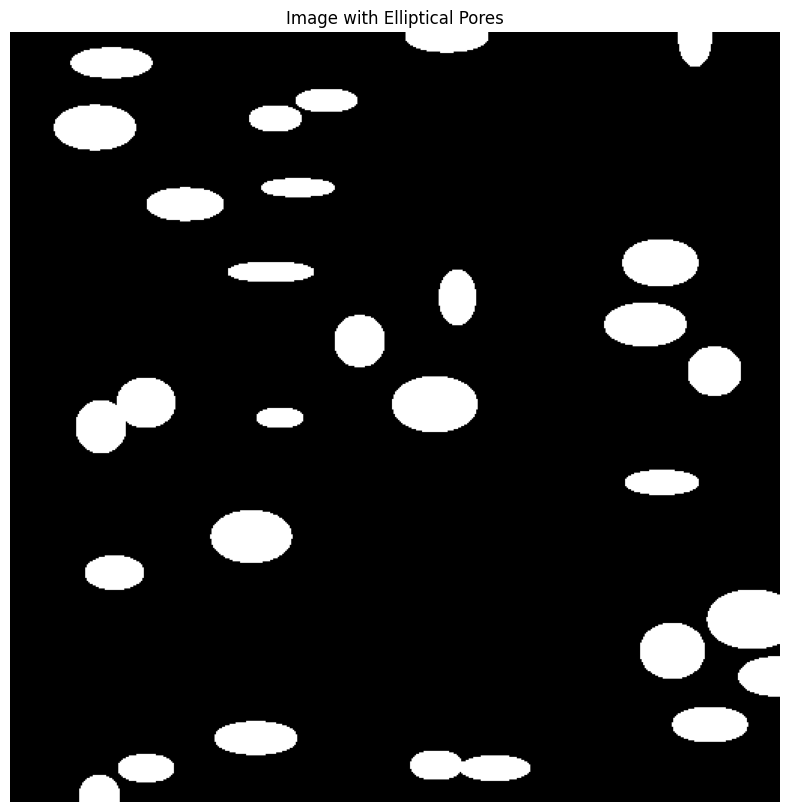

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, generate_binary_structure

def create_elliptical_pore_image(shape, a_range, b_range, num_pores, connectivity):
    """
    Generate a binary image with elliptical pores of varied sizes.
    
    Parameters:
        shape (tuple): Shape of the output image (height, width).
        a_range (tuple): Range (min, max) of semi-major axis lengths of the elliptical pores.
        b_range (tuple): Range (min, max) of semi-minor axis lengths of the elliptical pores.
        num_pores (int): Number of elliptical pores to generate.
        connectivity (float): Fraction of pores that are connected (0 to 1).
        
    Returns:
        np.ndarray: Binary image with elliptical pores.
    """
    image = np.zeros(shape, dtype=np.uint8)
    
    # Generate random positions for the pores
    pore_centers = np.random.randint(0, min(shape), size=(num_pores, 2))
    
    for center in pore_centers:
        h, k = center
        # Generate random semi-major and semi-minor axis lengths
        a = np.random.uniform(a_range[0], a_range[1])
        b = np.random.uniform(b_range[0], b_range[1])
        y, x = np.ogrid[:shape[0], :shape[1]]
        mask = ((x - h)**2 / a**2) + ((y - k)**2 / b**2) <= 1
        image[mask] = 1
    
    # Apply connectivity if necessary
    if connectivity > 0:
        struct = generate_binary_structure(2, 2)  # 8-connectivity structure
        num_iterations = int(connectivity * 10)  # Scale connectivity to a reasonable range
        image = binary_dilation(image, structure=struct, iterations=num_iterations)
    
    return image

def display_image(image):
    """
    Display a binary image.
    
    Parameters:
        image (np.ndarray): Binary image to display.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray')
    plt.title("Image with Elliptical Pores")
    plt.axis('off')
    plt.show()

# Parameters
shape = (512, 512)         # Image shape
a_range = (10, 30)         # Range of semi-major axis lengths of elliptical pores
b_range = (5, 20)          # Range of semi-minor axis lengths of elliptical pores
num_pores = 30            # Number of pores
connectivity = 0.1         # Fraction of pores that are connected

# Generate and display the image
image = create_elliptical_pore_image(shape, a_range, b_range, num_pores, connectivity)
display_image(image)

In [2]:
image.shape

(512, 512)

In [3]:
image.min(), image.max()

(False, True)

In [4]:
image = image.astype("uint8")

In [6]:
image.dtype, image.min(), image.max()

(dtype('uint8'), 0, 1)

In [8]:
from scipy import ndimage as ndi
# Create the label to separate the connected regions
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(image)

In [9]:
num_labels

28

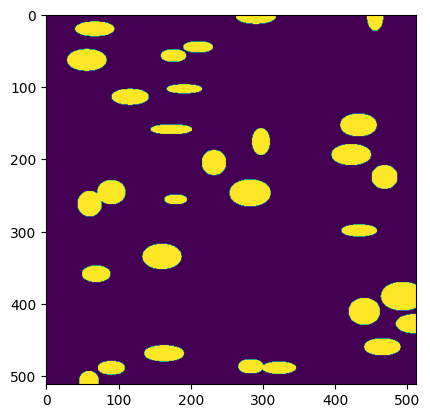

In [10]:
plt.imshow(image)

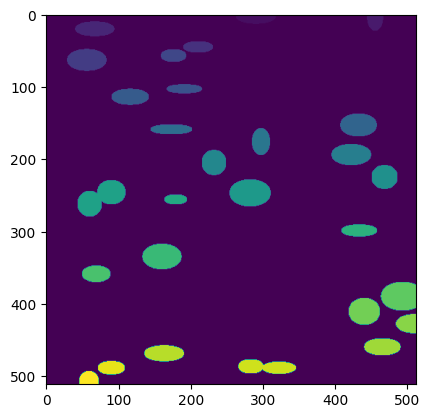

In [12]:
plt.imshow(labeled_image)

In [14]:
labeled_image.min(), labeled_image.max()

(0, 28)

In [16]:
import numpy as np

def separate_regions(labeled_image):
    # Get the unique region labels
    unique_labels = np.unique(labeled_image)
    
    # Initialize a list to store separated images
    separated_images = []
    
    # Iterate through each unique label (excluding the background label, if any)
    for label in unique_labels:
        # Create a mask for the current label
        region_mask = (labeled_image == label).astype(np.uint8)
        
        # Multiply the original labeled image by the mask to keep only the region
        separated_image = region_mask * labeled_image
        
        # Add the separated image to the list
        separated_images.append(separated_image)
    
    return separated_images

# # Example usage
# labeled_image = np.array([[0, 1, 1], [2, 2, 0], [0, 1, 1]])
separated_images = separate_regions(labeled_image)

#for i, img in enumerate(separated_images):
#    print(f"Region {i}:\n", img)


In [24]:
separated_images[3].max(), separated_images[3].min()

(3, 0)

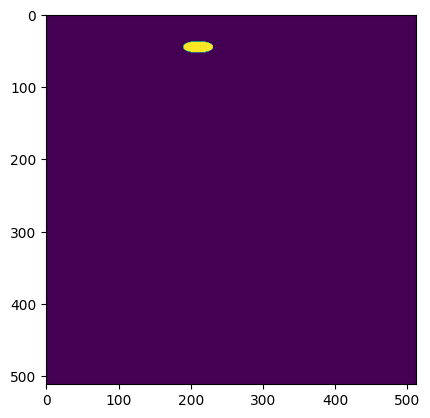

In [28]:
# 
plt.imshow(separated_images[4])

In [29]:
# Count the elements
import numpy as np

def count_elements_equal_to_value(array, value):
    # Count the number of elements in the array equal to the specified value
    count = np.sum(array == value)
    return count

In [69]:
value = 0 
n_elements = count_elements_equal_to_value(separated_images[0], value)
print("The number of elements equal:", value, "is",n_elements )

The number of elements equal: 0 is 262144


In [32]:
len(separated_images)

29

In [34]:
Count_elements = []
for i in range(1,len(separated_images)):
    n_el = count_elements_equal_to_value(separated_images[i],i)
    Count_elements.append(n_el)

In [67]:
Count_elements[4]

1329

The connected region number 26
The number of elements that is in the connected region is 583


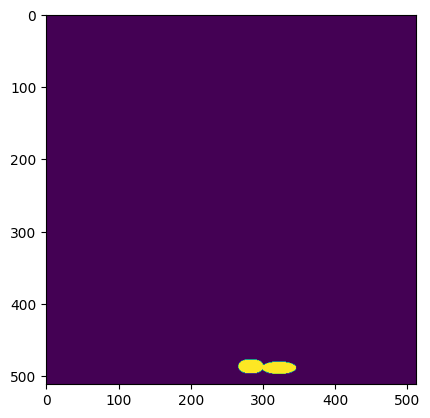

In [78]:
import random
check_index = random.randint(1,len(separated_images)-1)
print("The connected region number", check_index)
print("The number of elements that is in the connected region is", Count_elements[check_index])
plt.imshow(separated_images[check_index])